Now that we have shown that the k-fold models generalize better to the test data than a random baseline, we will generate a new model with the best hyperparameters identified, but trained on the training + validation data. This is simply to have one coherent model for additional downstream assessments. It also should give the model better power.

In [2]:
import os

import pandas as pd
import scanpy as sc

import torch
import torch.nn as nn
import numpy as np
from geomloss import SamplesLoss
from sklearn.metrics import normalized_mutual_info_score
from scipy import stats
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../.')
from Kang_utils import get_best_hyperparams


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [3]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainSC
from scLEMBAS.preprocess import discriminator_weight_curve, embed_tf_activity

In [4]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')

In [5]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

# ensures correct order of test data
# note, this already saved in order, matching the mod.y_out columns
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data

In [6]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [7]:
data_split_path = os.path.join(os.path.join(data_path, 'processed', 'data_split_barcodes'))
fold_keys = ['train_cells', 'val_cells', 'train_cond', 'val_cond']
k_fold_cells = {}
for k in range(5):
    k_fold_cells[k] = {fk: open(os.path.join(data_split_path, 'kang_' + str(k) + '_' + fk + '.txt')).read().splitlines()
                      for fk in fold_keys}

### Params

In [8]:
def generate_lr_params(n_epochs, max_lr, lr_scaling_factor = 10, lr_decay = 0.9):
    lr_period = 3 if n_epochs < 500 else 4
    lr_params = {'max_epochs': n_epochs, 
                 'maximum_learning_rate': max_lr, 
                 'minimum_learning_rate': max_lr/lr_scaling_factor,
                 'lr_restart_epoch': int(n_epochs/lr_period), 
                 'reset_optimizer_epoch': int(n_epochs/3), 
                'lr_decay': lr_decay, 
                 'lr_restart_factor': 1, 
                 'warmup_epochs': int(n_epochs/10)}
    return lr_params

def generate_discriminator_params(n_epochs, max_lr, discriminator_penalty_weight, 
                                  lr_scaling_factor = 10, lr_decay = 0.9):
    general_params = generate_lr_params(n_epochs, max_lr, lr_scaling_factor = lr_scaling_factor, 
                                        lr_decay = lr_decay)
    
    keys_to_keep = ['maximum_learning_rate', 'minimum_learning_rate', 'lr_restart_epoch', 
                   'warmup_epochs', 'lr_decay', 'reset_optimizer_epoch']
    discriminator_params = {'batch_momentum': 0.01,
                            'layer_norm': False,
                            'dropout_rate': 0.1,
                            'activation_fn': nn.LeakyReLU,
                            'n_hidden_nodes': [768, 512, 256],
                            'lr_restart_factor': 1,
                            'optimizer': torch.optim.Adam,
                            'discriminator_lambda_L2': 1e-3,
                            'discriminator_penalty_weight': discriminator_penalty_weight}
    discriminator_params = {**discriminator_params, 
                           **{k:v for k,v in general_params.items() if k in keys_to_keep}}
    
    return discriminator_params

In [9]:
# vae
n_layers_vae = 2
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

# linear scaling of inputs/outputs
projection_amplitude_in = 1
projection_amplitude_out = 1

# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 100 # 1 
                } 
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': vae_n_hidden_nodes, 
              'vae_var_min': 1e-4}
bionet_params = {**bionet_params, **vae_params}

# training parameters
other_params_default = {'network_noise_scale': 10, 'gradient_noise_scale': 1e-9, 
               'test_batch_size': np.nan}
spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, #50, 
                          'subset_n_spectral': 5} #10}
target_spectral_radius = 0.9

regularization_params_default = {'input_lambda_L2': 0, # doesn't matter if setting the requires grad to False
                         'bn_weights_lambda_l2': 1e-7, 
                         'bn_bias_lambda_L2': 0, # don't incorporate because of KL divergence
                         'output_weights_lambda_L2': 1e-7,
                         'output_bias_lambda_L2': 1e-7,
                         'moa_lambda_L1': 1e2,  
                         'uniform_lambda_L2': 1e-7,#, 1e-5,
                         'uniform_min': 0,
                         'uniform_max': 1, 
                         'spectral_loss_factor': 1e-6,
                        'vae_lambda_l2': 1e-7, 
                        'vae_scaling_KL': 1e-2}

In [9]:
# max_epochs_all = [600, 900, 1200]
# mpw_all = np.arange(5, 8.01, 0.25)
# b_all = np.arange(0.4, 1.21, 0.2)

# combs_all = list(itertools.product(max_epochs_all, mpw_all, b_all))
# max_lr = 0.0001
# train_batch = 512

# subset = 0.2 # 20% of grid

# combs = []
# counter = 0
# while ((900, 5.0, 0.4) not in combs) or ((1200, 5.0, 0.4) not in combs) or ((600, 5.0, 0.4) not in combs):
#     np.random.seed(seed + counter)
#     choice_idx = sorted(np.random.choice(range(len(combs_all)), int(np.floor(subset*len(combs_all)))))
#     combs = [comb for idx, comb in enumerate(combs_all) if idx in choice_idx]
#     counter += 1

In [10]:
max_epochs_all = [600, 900, 1200]
mpw_all = np.arange(5, 8.01, 0.25)
b_all = np.arange(0.4, 1.21, 0.2)

combs_all = list(itertools.product(mpw_all, b_all))

subset = 0.3 # fraction of grid

combs = []
counter = 0

while (5.0, 0.4) not in combs:
    np.random.seed(seed + counter)
    choice_idx = sorted(np.random.choice(range(len(combs_all)), int(np.floor(subset*len(combs_all)))))
    combs = [comb for idx, comb in enumerate(combs_all) if idx in choice_idx]
    counter += 1
combs = [(x, y[0], y[1]) for x, y in itertools.product(max_epochs_all, combs)]

max_lr = 0.0001
train_batch = 512

In [11]:
if os.path.isfile('/nobackup/users/hmbaghda/trash/res.csv'):
    res = pd.read_csv('/nobackup/users/hmbaghda/trash/res.csv', index_col = 0)
else:
    res = pd.DataFrame(columns = ['max_epochs', 'max_penalty_weight', 'b', 'disc_loss', 'nmi_global', 'nmi_cat'])
    


In [ ]:
for hyperparams in combs:
    max_epochs, max_penalty_weight, b = hyperparams
    if not (res.iloc[:, :3] == list(hyperparams)).all(axis=1).any():
        print('epochs: {} | max penalty: {:.1f} | b power: {:.2f}'.format(max_epochs, max_penalty_weight, b))
        k = 'all'
        if k == 'all':
            test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
            train_cells = [barcode for barcode in tf_adata.obs_names if barcode not in test_cells]
            val_cells = test_cells
        else:
            train_cells = k_fold_cells[k]['train_cells']
            test_cells = k_fold_cells[k]['val_cells']
            val_cells = test_cells



#         frac_no_adv = 0 # allow discriminator to fully learn the first fraction of epochs
#         n_no_adv = int(max_epochs*frac_no_adv)
        min_penalty_weight = 0.1
#         discriminator_penalty_weight = [min_penalty_weight/10]*n_no_adv
        discriminator_penalty_weight = discriminator_weight_curve(n_epochs = max_epochs,
                                                                       min_penalty_weight = min_penalty_weight,
                                                                       max_penalty_weight = max_penalty_weight, 
                                                                      a = 1, 
                                                                      b = b, 
                                                                          curve_type = 'power')

        lr_params = generate_lr_params(n_epochs = max_epochs, max_lr = max_lr, lr_scaling_factor = 10, lr_decay = 0.9)
        discriminator_params = generate_discriminator_params(n_epochs = max_epochs, max_lr = max_lr, 
                              discriminator_penalty_weight = discriminator_penalty_weight, 
                              lr_scaling_factor = 10, lr_decay = 0.9)
        # tune other parameters as a function of those being adjusted
        regularization_params = regularization_params_default.copy()
        other_params = {**other_params_default,
                        **{'train_batch_size': train_batch,
                           'validation_batch_size': len(val_cells)}}
        training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}


        mod = SignalingModel(net = sn_ppis,
                             X_in = pd.DataFrame(tf_adata.obs.stim.cat.codes, columns = ['IFNB1']),
                             y_out = tf_adata.to_df().copy(), 
                             expr = adata.to_df().copy(), 
                             covariates = tf_adata.obs.copy(),
                             categorical_covariate_keys = ['seurat_annotations'],
                             projection_amplitude_in = projection_amplitude_in, 
                             projection_amplitude_out = projection_amplitude_out,
                             weight_label = weight_label, source_label = source_label, target_label = target_label,
                             bionet_params = bionet_params, 
                             dtype = torch.float32, device = device, seed = seed)
        # model setup
        mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
        mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

        # training loop
        trainer = TrainSC(mod = mod,
                           prediction_optimizer = torch.optim.Adam,
                           prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                          discriminator_params = discriminator_params,
                           hyper_params = training_params,
                           train_split = {'train': train_cells, 'test': None, 'validation': val_cells}, 
                           train_seed = seed, 
                           track_test = False,
                           track_validation = False)
        mod = trainer.train_model(verbose = False)


        stim_map = {'STIM': 1, 'CTRL': 0}
        rev_stim = {'STIM': 'CTRL', 'CTRL': 'STIM'}
        # rev_stim_map = {k: int(not bool(v)) for k,v in stim_map.items()}

        cov_idx_map = dict(zip(mod.signaling_network.covariates['seurat_annotations'], 
                               mod.signaling_network.covariates_idx['seurat_annotations']))
        cov_rev_map = {v:k for k,v in cov_idx_map.items()}


        only_within_celltype = True # only change stim within a cell type
        full_expr, full_X, full_covariates = None, None, None

        for cond in tf_adata.obs.loc[test_cells, :].condition.unique():
            stim, ct = cond.split('^')

            if only_within_celltype:
                train_cells_cond = tf_adata.obs[(tf_adata.obs.index.isin(train_cells)) & 
                                                (tf_adata.obs['condition'] == rev_stim[stim] + '^' + ct)].index.tolist()
            else:
                train_cells_cond = train_cells

            expr_test = mod.df_to_tensor(mod.expr.loc[train_cells_cond, :])

            X_test_df = pd.DataFrame(data = {'IFNB1': [stim_map[stim]]*len(train_cells_cond)})
            X_test = mod.df_to_tensor(X_test_df)

            covariates_idx_test = torch.tensor([cov_idx_map[ct]]*len(train_cells_cond), 
                                               device = mod.device, dtype = torch.int64).view(-1,1)

            if full_expr is None:
                full_expr = expr_test
            else: 
                full_expr = torch.cat((full_expr, expr_test), dim = 0)

            if full_X is None:
                full_X = X_test
            else: 
                full_X = torch.cat((full_X, X_test), dim = 0)

            if full_covariates is None:
                full_covariates = covariates_idx_test
            else: 
                full_covariates = torch.cat((full_covariates, covariates_idx_test), dim = 0)    


        mod.eval()
        with torch.inference_mode():
            y_predicted, Y_full, biases = mod(X_in = full_X, covariates_idx = full_covariates, expr = full_expr)
            bias_global, bias_mu, bias_log_sigma_squared = biases
            bias_sigma = torch.exp(bias_log_sigma_squared/2.) + mod.signaling_network.vae.var_min

            bias_cats = torch.zeros_like(bias_global.T, device = mod.device, dtype = mod.dtype)
            for cat_group_idx in range(full_covariates.shape[1]):
                cat_group = mod.signaling_network._cat_group_idx[cat_group_idx]
                mod.signaling_network.cat_embeddings[cat_group].weight.data.masked_fill_(mask = mod.signaling_network.cat_embeddings_mask[cat_group], 
                                                                            value = 0.0)
                bias_cats += mod.signaling_network.cat_embeddings[cat_group](full_covariates[:,cat_group_idx]).T
            bias_tot = bias_global.T + bias_cats    

        discriminator = trainer.discriminator['discriminators']['seurat_annotations']
        loss_fn = nn.CrossEntropyLoss()

        discriminator.eval()
        with torch.inference_mode():
            discriminator_prediction = discriminator(bias_global)
            discriminator_loss = loss_fn(discriminator_prediction, full_covariates.view(-1)).detach().cpu().item()


        full_covariates = full_covariates.detach().cpu().numpy()
        bias_global = bias_global.detach().cpu().numpy()
        bias_tot = bias_tot.detach().cpu().numpy().T

        obs = pd.DataFrame(full_covariates)
        obs.columns = ['seurat_annotations']
        obs.seurat_annotations = obs.seurat_annotations.map(cov_rev_map)

        # full model
        bias_adata = sc.AnnData(X = bias_global, obs = obs)
        embed_tf_activity(bias_adata, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)
        nmi_global = normalized_mutual_info_score(bias_adata.obs.leiden, bias_adata.obs.seurat_annotations)

        # full model -- categorical information added
        bias_tot = sc.AnnData(X = bias_tot, obs = obs)
        embed_tf_activity(bias_tot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)
        nmi_cat = normalized_mutual_info_score(bias_tot.obs.leiden, bias_tot.obs.seurat_annotations)

        res.loc[res.shape[0], :] = [max_epochs, max_penalty_weight, b, 
                                    discriminator_loss, nmi_global, nmi_cat]
        res.to_csv('/nobackup/users/hmbaghda/trash/res.csv')

        if nmi_cat/nmi_global >= 5: 
            fn = 'e{}_p{:.1f}_b{:.2f}'.format(max_epochs, max_penalty_weight, b) + '.csv'
            fn = os.path.join('/nobackup/users/hmbaghda/trash/', fn)
            trainer.stats['train'].to_csv(fn)
            

In [ ]:
res = pd.read_csv('/nobackup/users/hmbaghda/trash/res.csv', index_col = 0)
res['ratio'] = res.nmi_cat/res.nmi_global
res = res.sort_values(by = ['max_epochs', 'ratio'], ascending = False)

In [16]:
res[res.max_epochs == 1200].head()

,max_epochs,max_penalty_weight,b,disc_loss,nmi_global,nmi_cat,ratio
65,1200.0,7.75,0.6,2.707478,0.023831,0.609393,25.571925
63,1200.0,7.50,0.4,2.754170,0.024972,0.626567,25.090892
61,1200.0,7.00,0.4,2.742188,0.048103,0.598748,12.447333
56,1200.0,6.00,0.6,2.633056,0.051094,0.601778,11.777785
60,1200.0,6.75,1.2,2.639651,0.089690,0.601193,6.702979


In [17]:
res[res.max_epochs == 900].head()

,max_epochs,max_penalty_weight,b,disc_loss,nmi_global,nmi_cat,ratio
48,900.0,7.75,1.2,2.687271,0.056850,0.605466,10.650256
46,900.0,7.50,0.8,2.734945,0.058346,0.611638,10.482998
47,900.0,7.75,0.6,2.779932,0.060559,0.595456,9.832594
45,900.0,7.50,0.4,2.775638,0.065191,0.612113,9.389475
16,900.0,6.75,0.4,2.717290,0.066131,0.610035,9.224677


In [18]:
res[res.max_epochs == 600].head()

,max_epochs,max_penalty_weight,b,disc_loss,nmi_global,nmi_cat,ratio
29,600.0,7.25,0.4,2.712620,0.051741,0.609219,11.774394
30,600.0,7.50,0.4,2.822486,0.068658,0.596461,8.687432
28,600.0,7.00,0.4,2.707133,0.072491,0.615409,8.489408
9,600.0,7.25,0.6,2.748967,0.075924,0.620565,8.173538
32,600.0,7.75,0.6,2.713216,0.086682,0.607253,7.005539


In [ ]:
7.75 0.6
7.5 0.4

In [42]:
max_epochs = 900
max_penalty_weight = 7.75

b = 0.6

fn = 'e{}_p{:.1f}_b{:.2f}'.format(max_epochs, max_penalty_weight, b) + '.csv'
fn = os.path.join('/nobackup/users/hmbaghda/trash/', fn)
train_stats_df = pd.read_csv(fn, index_col = 0)
train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() 


/tmp/ipykernel_4096541/2109838773.py:34: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
/tmp/ipykernel_4096541/2109838773.py:60: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])


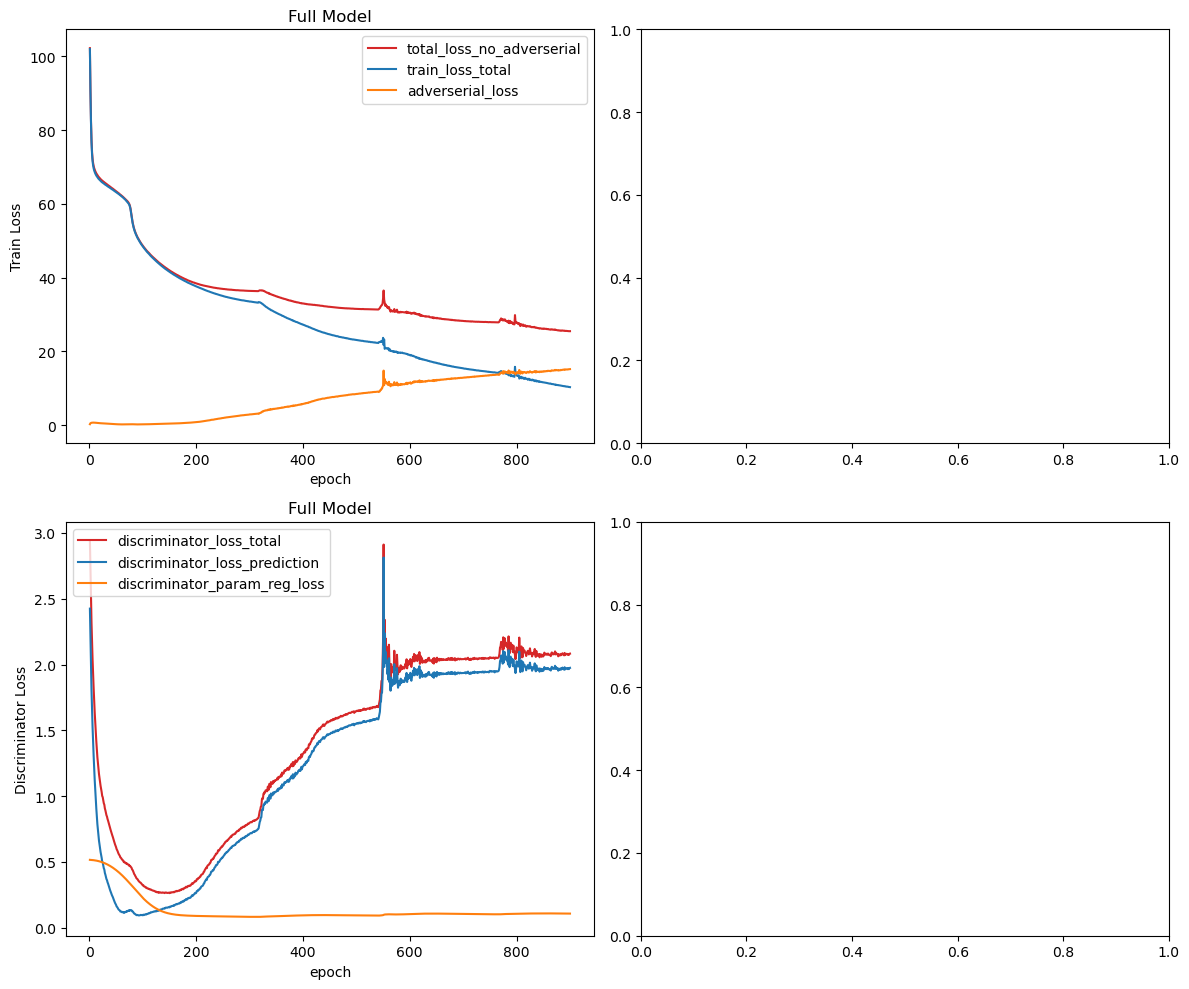

In [43]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,10))
ax = ax.flatten()

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# Plot 1: full model, adverserial loss
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']
loss_cols = ['train_loss_total'] + loss_cols_main + ['adverserial_loss']

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
ax[0].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
ax[0].set_ylabel('Train Loss')
ax[0].set_title('Full Model')

# # Plot 2: model no adverserial, adverserial loss
# viz_df = train_stats_df_na[['epoch'] + loss_cols].copy()
# viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
# viz_df.drop(columns = loss_cols_main, inplace = True)
# viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
# viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

# sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
# ax[1].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
# ax[1].set_ylabel('Train Loss')
# ax[1].set_title('No Adverserial Model')


# Plot 3: full model, discriminator loss
loss_cols_disc = ['discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])
# n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
# ax[2].axhline(y=np.log(n_cat), color='gray', linestyle='--')

ax[2].legend(loc='best')
ax[2].set_ylabel('Discriminator Loss')
ax[2].set_title('Full Model')

# # Plot 4: model no adverserial, discriminator loss
# viz_df = train_stats_df_na[['epoch'] + loss_cols_disc].copy()
# viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
# viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

# sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[3])
# n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
# ax[3].axhline(y=np.log(n_cat), color='gray', linestyle='--')

# ax[3].legend(loc='best')
# ax[3].set_ylabel('Discriminator Loss')
# ax[3].set_title('No Adverserial Model')


fig.tight_layout()